<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB10(8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 8

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load dataset (downloads automatically ~170MB)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values 0-255 → 0-1
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Class names (these are the 10 CIFAR-10 categories)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog',      'frog',       'horse','ship','truck']

print("Training samples :", x_train.shape)   # (50000, 32, 32, 3)
print("Test samples     :", x_test.shape)    # (10000, 32, 32, 3)
print("Classes          :", CLASS_NAMES)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training samples : (50000, 32, 32, 3)
Test samples     : (10000, 32, 32, 3)
Classes          : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipykernel_2990/3194887812.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASS_NAMES[int(y_train[i])], fontsize=7)


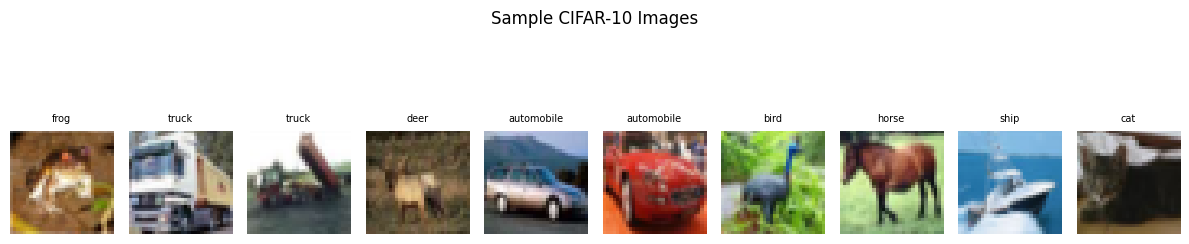

In [ ]:
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[int(y_train[i])], fontsize=7)
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
model = models.Sequential([

    # Block 1 — detects edges and colors
    layers.Conv2D(32, (3,3), activation='relu',
                  padding='same', input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2 — detects shapes and textures
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,  activation='softmax')   # 10 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.3716 - loss: 1.7161 - val_accuracy: 0.5504 - val_loss: 1.2551
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5352 - loss: 1.2933 - val_accuracy: 0.6350 - val_loss: 1.0319
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5998 - loss: 1.1303 - val_accuracy: 0.6746 - val_loss: 0.9503
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6347 - loss: 1.0309 - val_accuracy: 0.6872 - val_loss: 0.8780
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6596 - loss: 0.9675 - val_accuracy: 0.7256 - val_loss: 0.7773
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6878 - loss: 0.8966 - val_accuracy: 0.7288 - val_loss: 0.7874
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6977 - loss: 0.8618 - val_accuracy: 0.7450 - val_loss: 0.7295
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7126 - loss: 0.8197 - val_accuracy: 

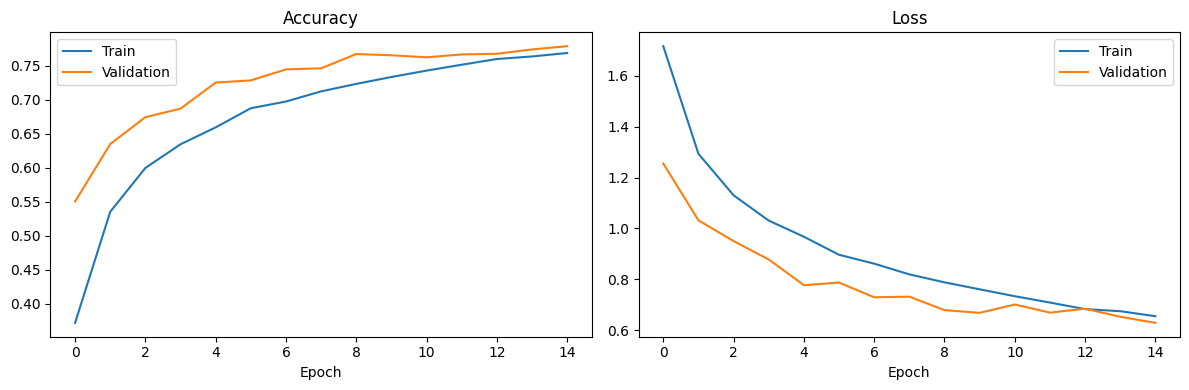

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout(); plt.show()

In [ ]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.2%}")

Test Accuracy: 76.98%


Filter shape: (3, 3, 3, 32)


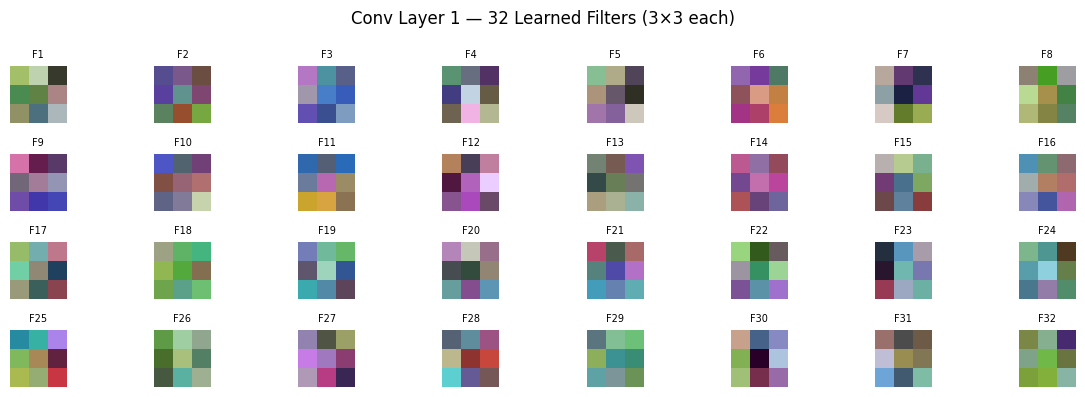

In [ ]:
# Get weights of first conv layer
filters, biases = model.layers[0].get_weights()

print(f"Filter shape: {filters.shape}")
# Shape is (3, 3, 3, 32) = (height, width, channels, num_filters)

# Normalize filter values to 0-1 for display
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

# Plot all 32 filters
plt.figure(figsize=(12, 4))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.imshow(filters_norm[:, :, :, i])   # show as RGB patch
    plt.title(f"F{i+1}", fontsize=7)
    plt.axis('off')

plt.suptitle("Conv Layer 1 — 32 Learned Filters (3×3 each)", fontsize=12)
plt.tight_layout()
plt.show()

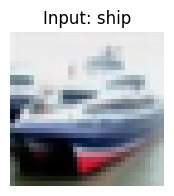

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
Feature map shape: (1, 32, 32, 32)


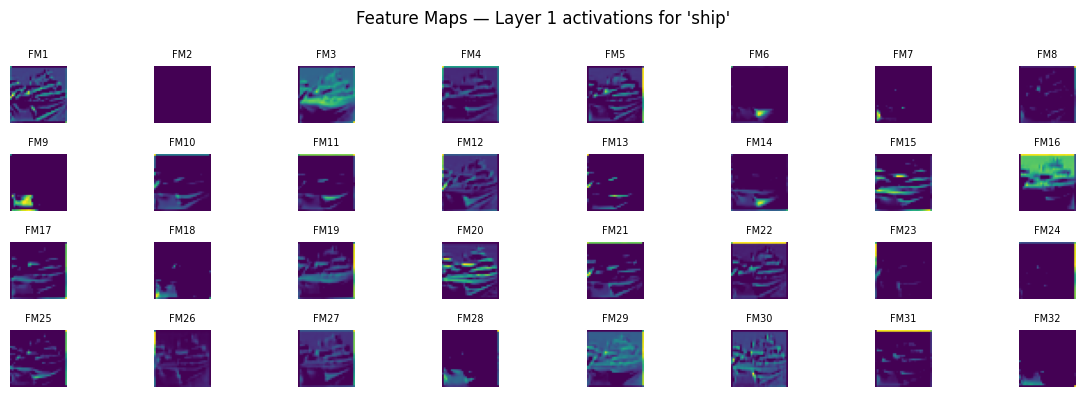

In [ ]:
# Pick one test image
sample_img = x_test[1:2]                        # shape (1, 32, 32, 3)
true_label = CLASS_NAMES[int(y_test[1].item())] # .item() fixes the deprecation warning

# Show the input image
plt.figure(figsize=(2, 2))
plt.imshow(sample_img[0])
plt.title(f"Input: {true_label}"); plt.axis('off'); plt.show()

# FIX: Rebuild model explicitly with functional API to expose input/output
inp  = tf.keras.Input(shape=(32, 32, 3))
x    = inp
for layer in model.layers:
    x = layer(x)

# Feature model that stops at first Conv layer output
feat_model   = tf.keras.Model(inputs=inp,
                               outputs=model.layers[0](inp))
feature_maps = feat_model.predict(sample_img)   # shape (1, 32, 32, 32)

print("Feature map shape:", feature_maps.shape)

# Plot all 32 feature maps
plt.figure(figsize=(12, 4))
for i in range(32):
    plt.subplot(4, 8, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"FM{i+1}", fontsize=7)
    plt.axis('off')

plt.suptitle(f"Feature Maps — Layer 1 activations for '{true_label}'", fontsize=12)
plt.tight_layout()
plt.show()

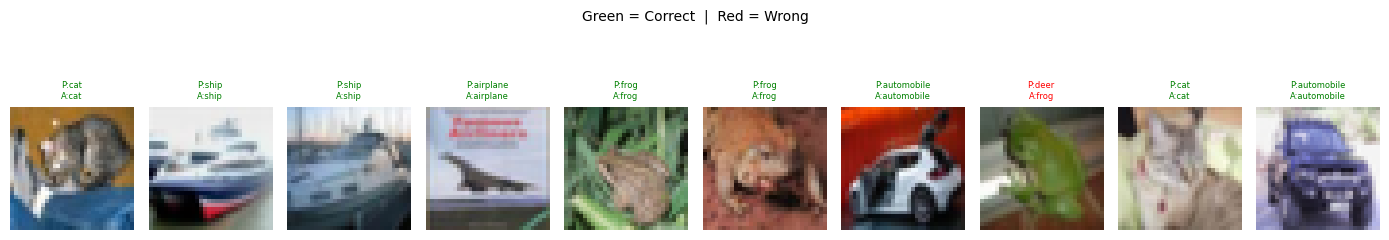

In [ ]:
predictions = model.predict(x_test[:10], verbose=0)

plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i])
    pred   = CLASS_NAMES[np.argmax(predictions[i])]
    actual = CLASS_NAMES[int(y_test[i].item())]
    color  = 'green' if pred == actual else 'red'
    plt.title(f"P:{pred}\nA:{actual}", fontsize=6, color=color)
    plt.axis('off')

plt.suptitle("Green = Correct  |  Red = Wrong", fontsize=10)
plt.tight_layout()
plt.show()